# **Probability of Default Prediction Model**
#### **Problem Statement**
You just been appointed as Data Scientist and your first task is to create Expected Loss Model. Consisting of Probability of Default (PD) model, a loss given default (LGD) model, and an exposure-at-default (EAD) model for a portfolio of individual’s credits. But for this time we can start from the PD Model first in order to predict loan defaults based on loan application. 

You can create feature engineering by using any combination of the features in the dataset to make your predictions accuracy higher. Some features will be easier to use than others.

| Variable | Definition |
|---|---|
| Loan_ID | A unique id for the loan. |
| Grade | The grade of the loan (e.g. A, B, C, ...). |
| Home_Ownership | The home ownership status provided by the borrower during registration. Values are: Rent, Own, Mortgage. |
| Purpose | A category provided by the borrower for the loan request. |
| Verification_Status | Indicates if income was verified, not verified, or if the income source was verified. |
| Term | Credit term period (in months). |
| Emp_Length_Int | Employment length in years. |
| Mths_Since_Issue_D | The number of months since the borrower's last loan issue date. |
| Int_Rate | Interest rate of the loan application. |
| Mths_Since_Earliest_Cr_Line | The number of months since the borrower's first loan issue date. |
| Acc_Now_Delinq | The total number of loan account that currently delinquent. |
| Inq_Last_6mths | The number of inquiries by borrowers during the past 6 months. |
| Annual_Inc | The annual income provided by the borrower during registration. |
| Dti | A ratio calculated using the borrower's total monthly debt payments on the total debt obligations, excluding mortgage and the requested loan, divided by the borrower's self-reported monthly income. |
| Good_Bad | Indicates if the loan was good or bad (0 = default, 1 = non-default) |

### Documentation Guide

This notebook is the **Model Development Documentation** deliverable. It walks through the full workflow used to build the Probability of Default (PD) model, in the order requested in the brief:

1. **Data Preparation & Exploration (EDA)** — discoveries, chart-based univariate analysis, predictive power, missing values, outliers, and feature engineering ideas.
2. **Model Development** — three candidate algorithms, cross-validated benchmarking, hyperparameter optimization, and the final refit.
3. **Model Evaluation** — accuracy, precision, recall, F1, log loss, AUC, and a discussion of the confusion-matrix behaviour, plus the final model choice and rationale.

No code in the cells below has been modified — only markdown explanations have been added between the existing code cells so the notebook fully documents *what* each step does and *why*, and answers every question asked in the assignment brief.

## **Data Preparation & Exploration (EDA)**

**Setup.** We import the standard data-science stack (`pandas`, `numpy`), plotting libraries (`matplotlib`, `seaborn`), and suppress non-critical warnings so the notebook output stays readable. The raw training data (`pd_loan_data_train.csv`) is loaded into `df`. This is the dataset we will explore, clean, engineer features on, and use to train/validate the models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/pd_loan_data_train.csv')

**First look at the data.** `df` contains one row per loan application. Displaying it gives us a quick sanity check on column names, data types at a glance, and the general shape of a lending dataset (borrower attributes such as `grade`, `home_ownership`, `purpose`, plus loan terms and the `good_bad` target).

In [2]:
df

,loan_id,grade,home_ownership,purpose,verification_status,term,emp_length_int,mths_since_issue_d,int_rate,mths_since_earliest_cr_line,acc_now_delinq,inq_last_6mths,annual_inc,dti,good_bad
0,14840,C,RENT,debt_consolidation,Verified,60 months,7,54,15.80,231,0.0,1,105000.0,7.56,1
1,20011,B,RENT,debt_consolidation,Verified,36 months,2,47,9.67,145,0.0,0,54000.0,24.64,1
2,8415,E,RENT,debt_consolidation,Verified,60 months,0,48,21.48,118,0.0,2,30000.0,17.76,1
3,7876,A,RENT,debt_consolidation,Source Verified,36 months,10,71,7.90,216,NaN,0,35000.0,21.87,1
4,11837,C,MORTGAGE,major_purchase,Source Verified,36 months,10,46,14.16,202,0.0,1,62570.0,12.54,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,616,B,RENT,debt_consolidation,Not Verified,36 months,10,36,8.67,198,0.0,0,65000.0,21.81,1
20396,4237,C,RENT,debt_consolidation,Source Verified,36 months,1,40,12.99,335,0.0,0,50000.0,14.69,1
20397,18441,D,OWN,credit_card,Verified,60 months,7,50,17.76,270,0.0,0,68000.0,26.70,1
20398,26253,C,MORTGAGE,credit_card,Verified,60 months,2,40,13.35,329,0.0,1,78000.0,7.63,1


**Discovery — schema & missing values.** `df.info()` shows **20,400 rows and 15 columns**. Every column is fully populated (20,400 non-null) **except `acc_now_delinq`**, which has some missing values — this is the only data-cleanliness issue in the dataset and is investigated further below. Feature types are a mix of numeric (`emp_length_int`, `mths_since_issue_d`, `int_rate`, `mths_since_earliest_cr_line`, `acc_now_delinq`, `inq_last_6mths`, `annual_inc`, `dti`) and categorical/object (`grade`, `home_ownership`, `purpose`, `verification_status`, `term`).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loan_id                      20400 non-null  int64  
 1   grade                        20400 non-null  object 
 2   home_ownership               20400 non-null  object 
 3   purpose                      20400 non-null  object 
 4   verification_status          20400 non-null  object 
 5   term                         20400 non-null  object 
 6   emp_length_int               20400 non-null  int64  
 7   mths_since_issue_d           20400 non-null  int64  
 8   int_rate                     20400 non-null  float64
 9   mths_since_earliest_cr_line  20400 non-null  int64  
 10  acc_now_delinq               19044 non-null  float64
 11  inq_last_6mths               20400 non-null  int64  
 12  annual_inc                   20400 non-null  float64
 13  dti             

**Discovery — uniqueness of the ID column.** `loan_id` has 20,400 unique values, matching the row count exactly. This confirms `loan_id` is a true primary key with no duplicate applications, and confirms it carries no predictive signal (it's an identifier), so it is safe to drop before modeling.

In [4]:
df['loan_id'].nunique()

20400

**How clean is the data / is there missing data?** `acc_now_delinq` is missing in about **6.65%** of rows. This is the only column with missing values in the whole dataset.

In [5]:
df['acc_now_delinq'].isna().mean()*100

np.float64(6.647058823529411)

**Target distribution.** `good_bad` (1 = non-default / good loan, 0 = default / bad loan) is **imbalanced**: roughly 17,487 good loans vs. 2,913 bad loans (~14% default rate). This class imbalance is an important consideration for model development — it motivates using `class_weight="balanced"` for Logistic Regression / Random Forest, choosing AUC / F1 / recall (rather than raw accuracy alone) as the primary evaluation metrics, and using stratified sampling/cross-validation so every fold preserves this ratio.

In [6]:
df['good_bad'].value_counts()

good_bad
1    17487
0     2913
Name: count, dtype: int64

**Investigating `acc_now_delinq`.** The value counts show `acc_now_delinq` is heavily concentrated at 0 (no currently-delinquent accounts), with only a small number of loans having 1–3 delinquent accounts. Combined with its skew and missingness, this column is a candidate for exclusion (checked next by looking at whether missingness relates to the target, i.e. whether it is missing-not-at-random).

In [7]:
df['acc_now_delinq'].value_counts()

acc_now_delinq
0.0    18969
1.0       64
2.0       10
3.0        1
Name: count, dtype: int64

**Is the missingness informative?** We check the `good_bad` distribution specifically for rows where `acc_now_delinq` is missing. If the missing rows show a good/bad split similar to the overall population, the missingness is effectively random with respect to the target and the column adds little value once its 6.6% missing rate and heavy zero-skew are factored in — supporting the decision (made later in Feature Engineering) to drop `acc_now_delinq` rather than impute it.

In [8]:
df[df['acc_now_delinq'].isna()]['good_bad'].value_counts()

good_bad
1    1164
0     192
Name: count, dtype: int64

### Predictive Power — Categorical Features

For every categorical column we (1) print its unique categories, (2) run a **Chi-Square test of independence** against `good_bad` to statistically test whether the category is associated with default, and (3) plot the **good-rate by category** as a bar chart (with the actual rate labeled on each bar) so the direction and size of the effect is visible, not just its statistical significance.

- **p-value < 0.05 → "Significant"**: the feature's categories have meaningfully different default rates and the feature carries predictive signal.
- **p-value ≥ 0.05 → "Not Significant"**: the categories behave similarly and the feature is a weaker candidate.

This loop is applied to `grade`, `home_ownership`, `purpose`, `verification_status`, and `term`. In practice, `grade` and `term` tend to show the strongest, most monotonic relationship with default rate (consistent with them being risk-grading fields used by the lender itself), while some `purpose` categories are noisier due to smaller sample sizes.


 grade column has ['C' 'B' 'E' 'A' 'D' 'F' 'G'] unique values
Chi-Square p-value: 6.122340446063568e-176
Significant


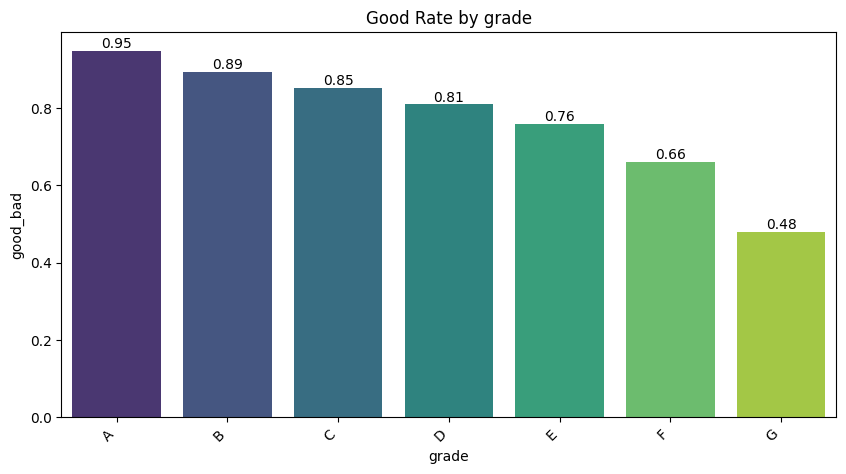


 home_ownership column has ['RENT' 'MORTGAGE' 'OWN'] unique values
Chi-Square p-value: 2.1916724739322234e-15
Significant


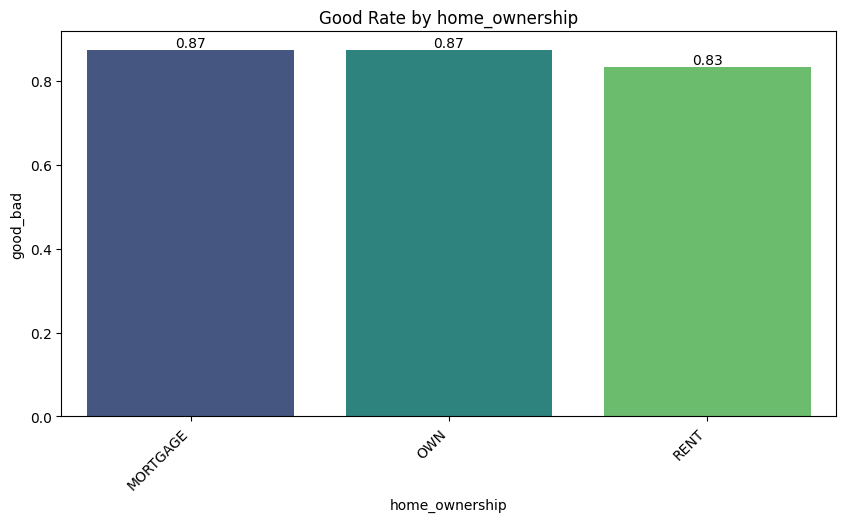


 purpose column has ['debt_consolidation' 'major_purchase' 'home_improvement' 'credit_card'
 'medical' 'vacation' 'other' 'moving' 'small_business' 'house' 'wedding'
 'car' 'educational' 'renewable_energy'] unique values
Chi-Square p-value: 2.0572964696740206e-15
Significant


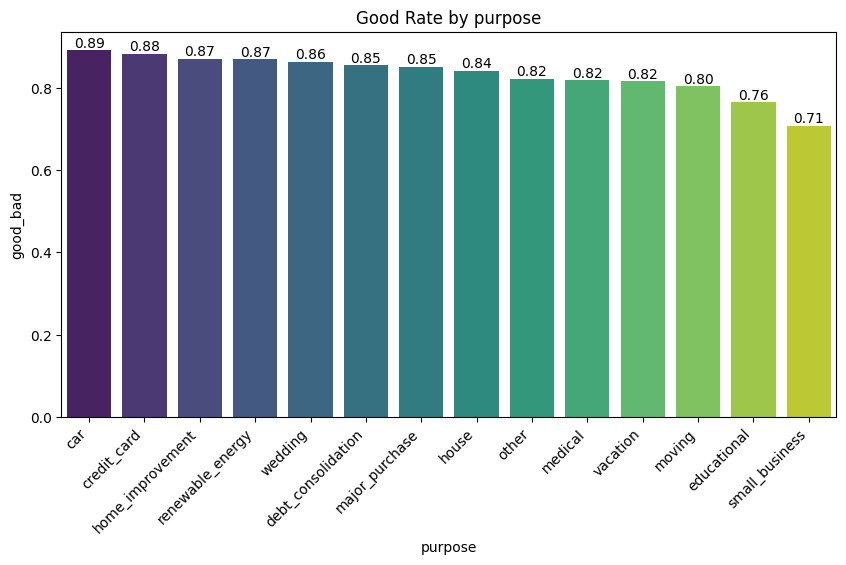


 verification_status column has ['Verified' 'Source Verified' 'Not Verified'] unique values
Chi-Square p-value: 1.20757567548886e-12
Significant


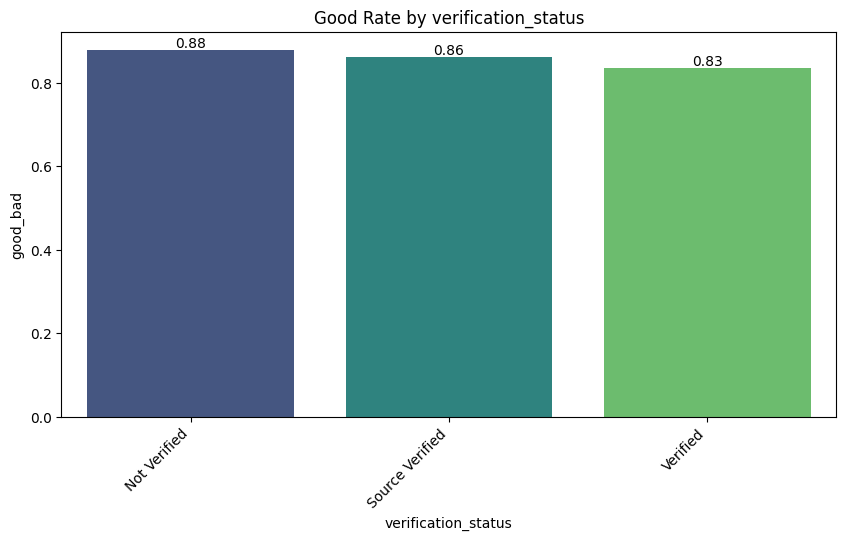


 term column has ['60 months' '36 months'] unique values
Chi-Square p-value: 5.829411805053665e-27
Significant


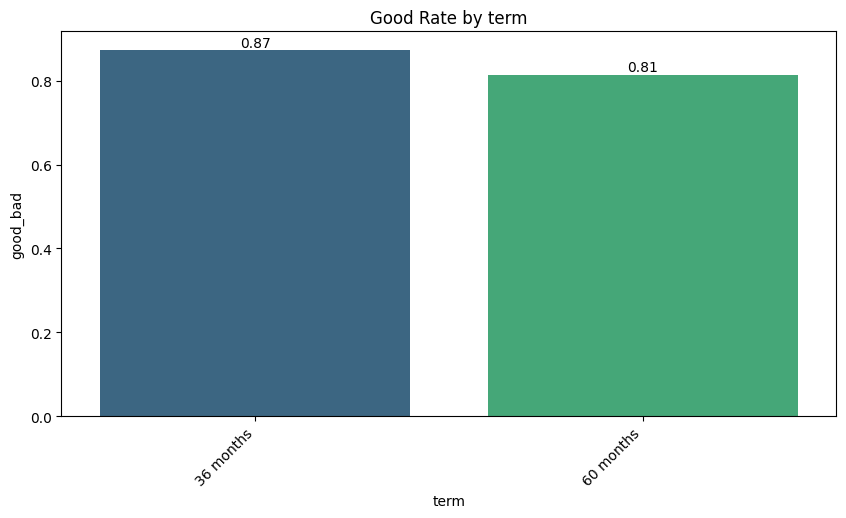

In [9]:
from scipy.stats import chi2_contingency
for col in df.select_dtypes(exclude='number'):
    print(f'\n {col} column has {df[col].unique()} unique values')
    ct = pd.crosstab(df[col], df['good_bad'])
    
    # Run the test
    chi2, p_val, dof, expected = chi2_contingency(ct)
    print(f'Chi-Square p-value: {p_val}')
    
    # Interpret the result (using standard alpha = 0.05)
    if p_val < 0.05:
        print(f"Significant")
    else:
        print(f"Not Significant")
        
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data = df.groupby([col])['good_bad'].mean().reset_index().sort_values('good_bad', ascending=False), x=col, y='good_bad', palette='viridis')
    for cont in ax.containers:
        ax.bar_label(cont, fmt='%.2f')
    plt.title(f'Good Rate by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.show()

### Predictive Power — Numeric Features

For every numeric feature (excluding the ID and the target) we plot:

- An **ECDF** split by `good_bad`, so any horizontal separation between the two curves indicates the feature discriminates between good and bad loans.
- A **boxplot** split by `good_bad`, which also makes outliers visible (points beyond the whiskers).

We complement the visuals with a **Mann-Whitney U test** (a non-parametric test that doesn't assume normally-distributed data, appropriate here given the skew in variables like `annual_inc`) comparing the good vs. bad groups for each feature, and report whether the difference is statistically significant.

**Outliers:** the boxplots reveal right-skew/heavy tails in variables such as `annual_inc`, `dti`, and `int_rate` — a small number of high-income or high-interest-rate applicants sit far from the bulk of the distribution. Rather than deleting these observations (which would throw away real applicants), the main heavy-tailed variable (`annual_inc`) is **log-transformed** in the next step to compress its scale and reduce the influence of extreme values, and later all numeric features are passed through a `StandardScaler`, which further limits the effect of scale/outliers on distance- and gradient-based models.

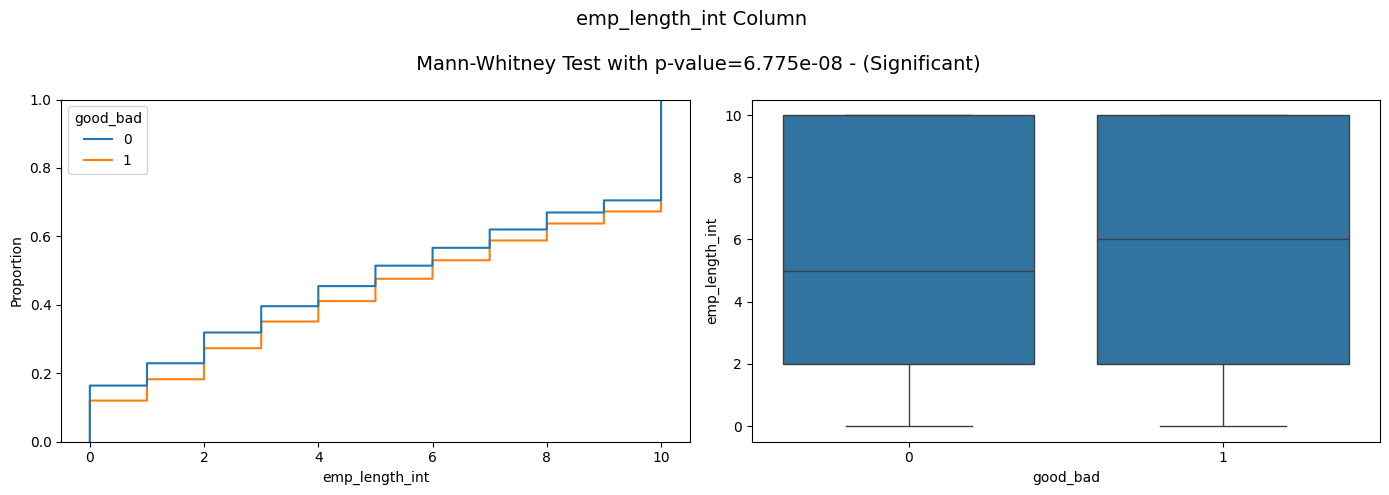

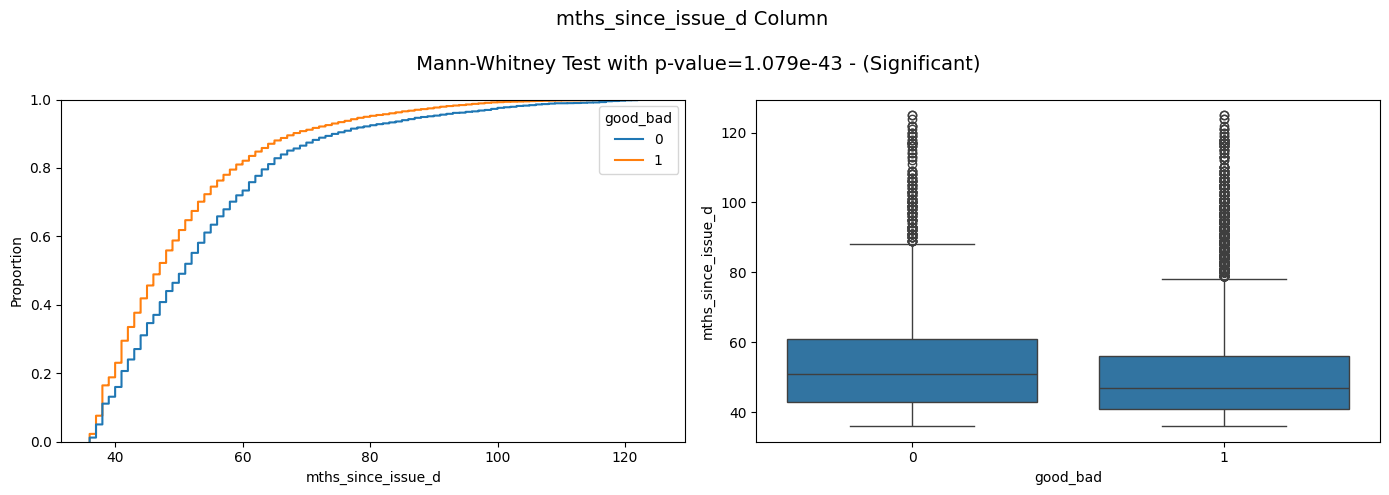

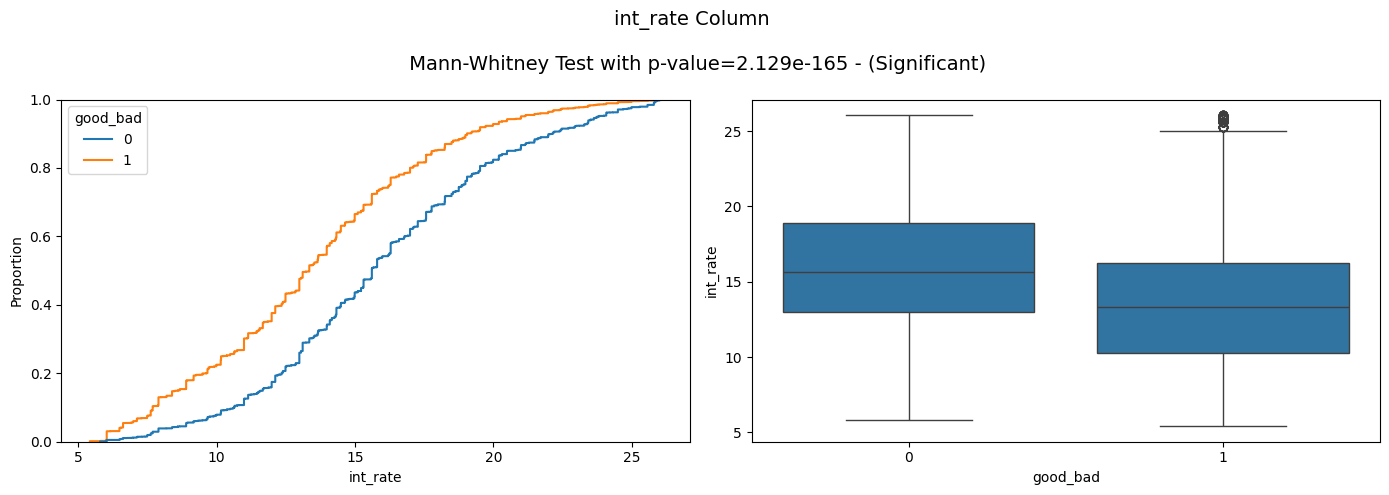

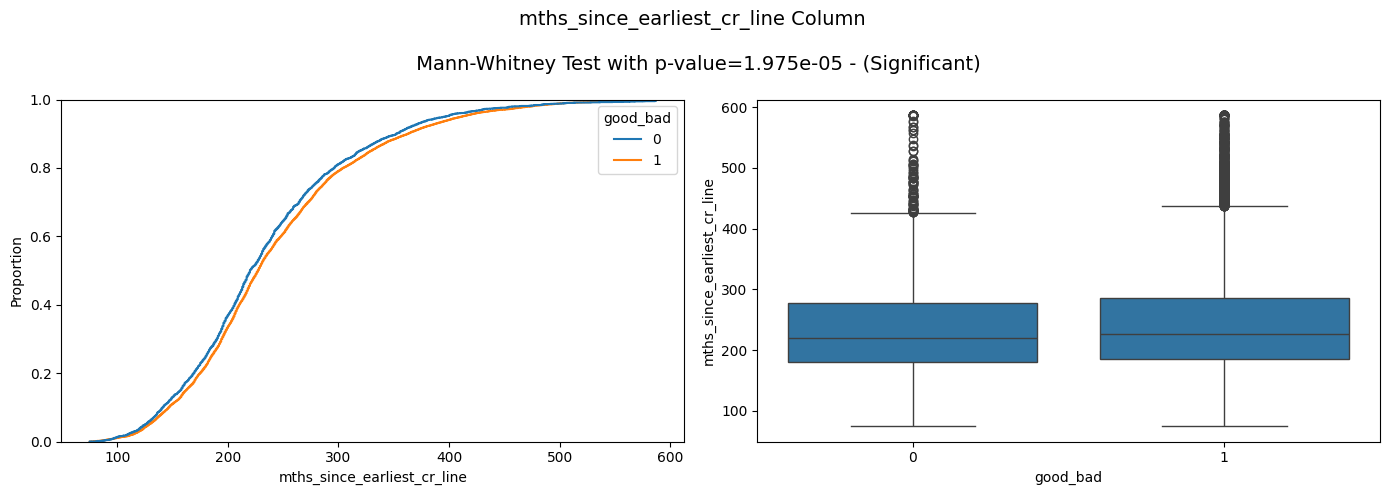

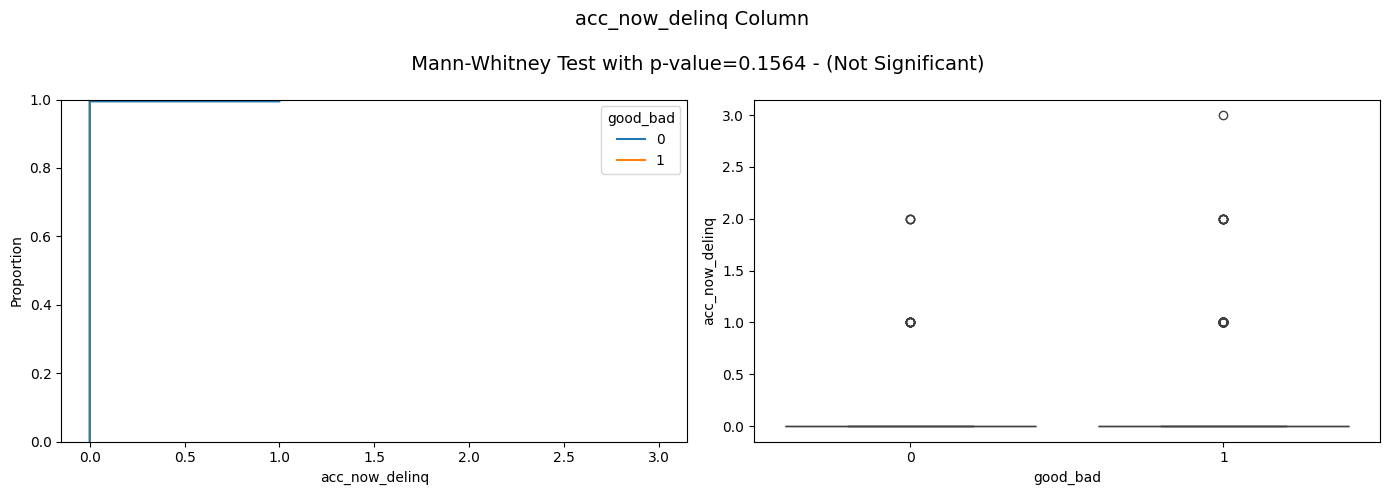

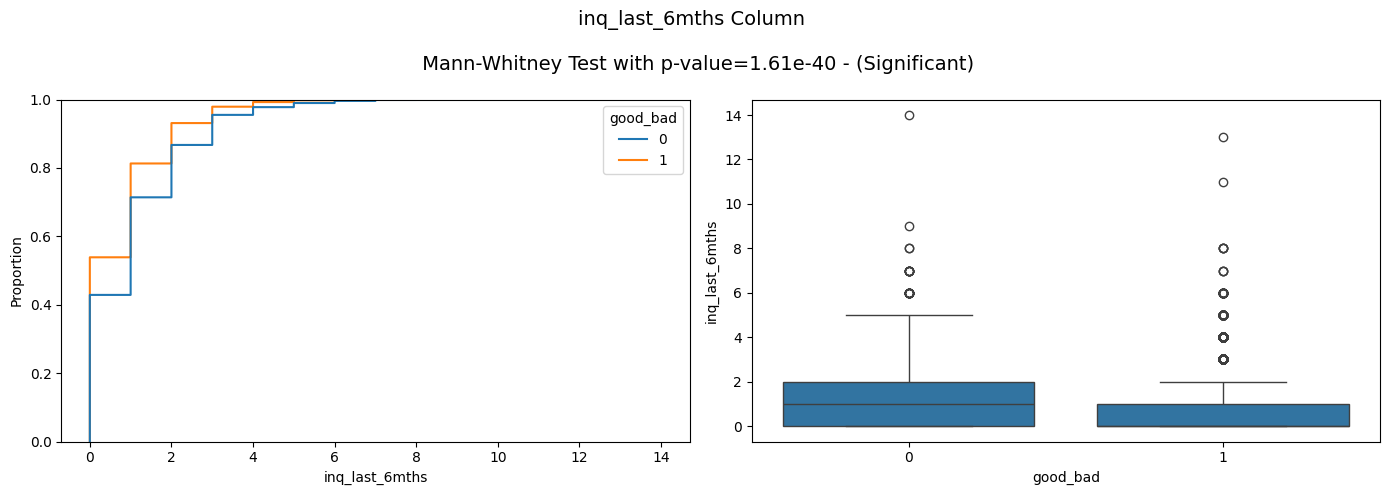

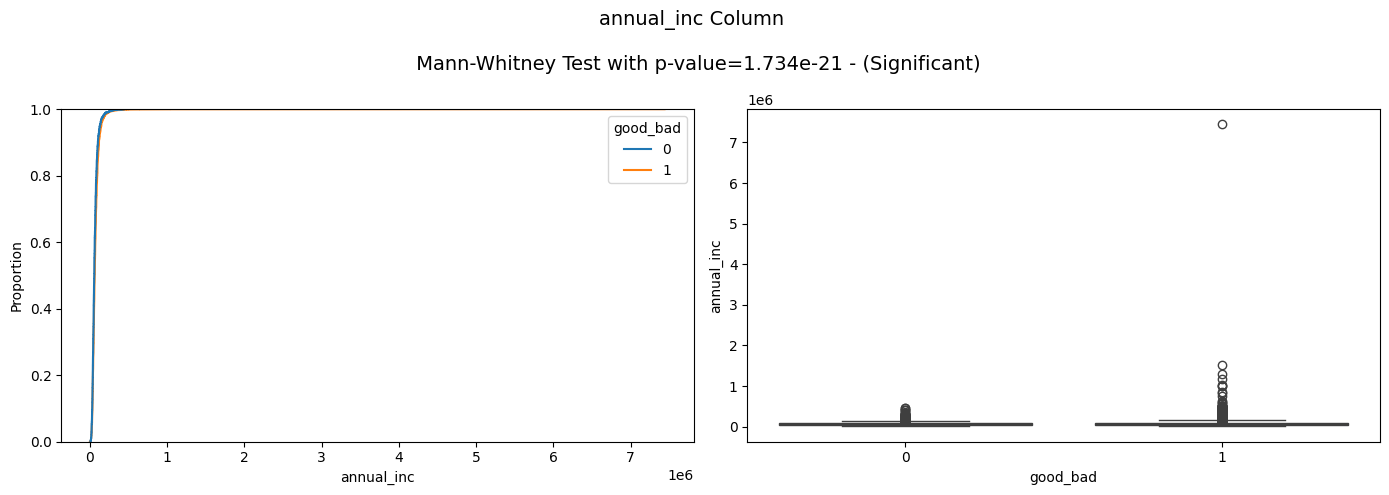

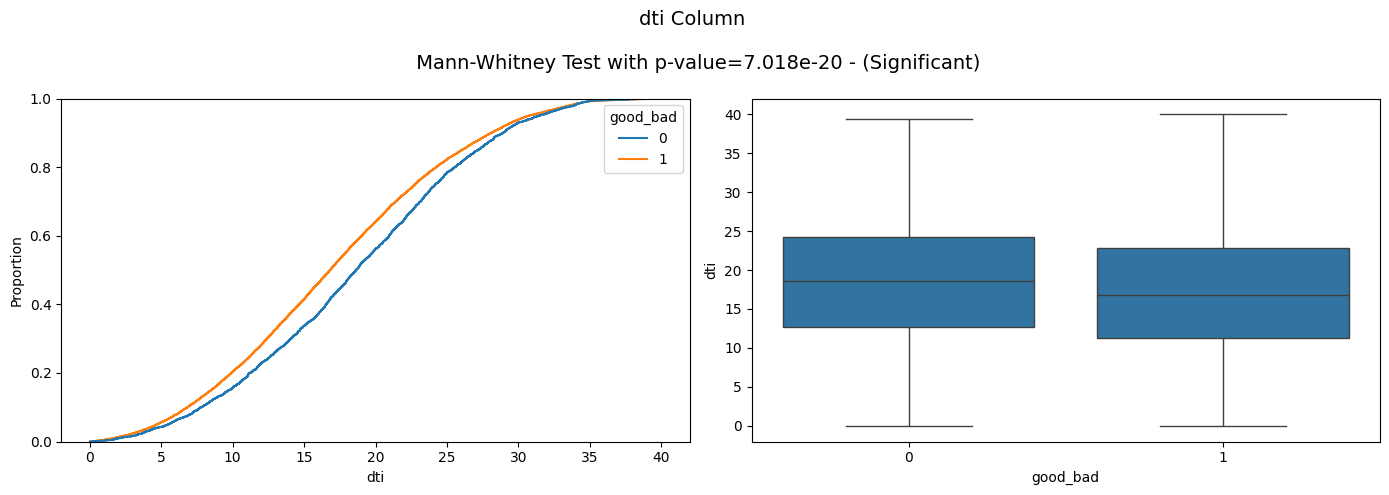

In [10]:
from scipy.stats import mannwhitneyu

for col in df.drop(['loan_id', 'good_bad'], axis = 1).select_dtypes(include='number').columns:
    fig, axes = plt.subplots(1,2, figsize=(14,5))

    # ECDF
    sns.ecdfplot(
        data=df,
        x=col,
        hue='good_bad',
        ax=axes[0]
    )

    # Boxplot
    sns.boxplot(
        data=df,
        x='good_bad',
        y=col,
        ax=axes[1]
    )

    # Mann Whitney Test
    good = df.loc[df['good_bad']==0, col].dropna()
    bad  = df.loc[df['good_bad']==1, col].dropna()

    stat, p = mannwhitneyu(good, bad, alternative='two-sided')

    if p < 0.05:
        result = "Significant"
    else:
        result = "Not Significant"

    fig.suptitle(
        f"{col} Column \n\n Mann-Whitney Test with p-value={p:.4g} - ({result})",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

**Should we add a new variable to increase predictive power?** `annual_inc` is strongly right-skewed (a handful of very high earners). We engineer `annual_inc_log = log1p(annual_inc)` and re-run the ECDF/boxplot/Mann-Whitney comparison on the transformed variable. A log transform doesn't add new information, but it re-expresses income on a scale where the relationship with default risk is more linear and less dominated by outliers — which typically **improves how well Logistic Regression can use the feature**, and makes the boxplot comparison easier to read. This engineered feature (`log_annual_inc`) is carried forward into modeling in place of raw `annual_inc`.

Text(0.5, 0.98, 'annual_inc_log Column \n Mann-Whitney Test with p-value=1.734e-21 - (Significant)')

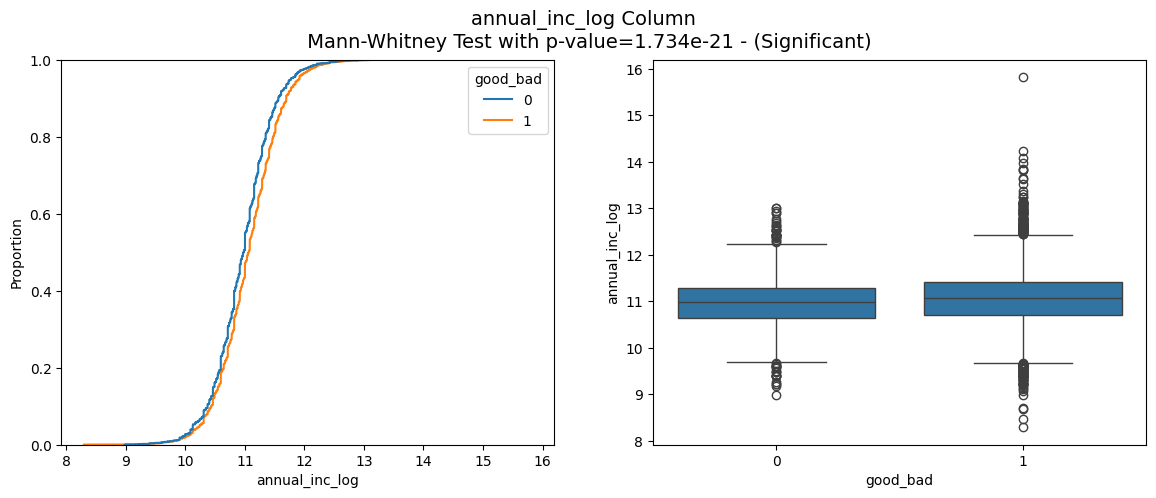

In [11]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
_df = df.copy()
_df['annual_inc_log'] = np.log1p(df['annual_inc'])
# ECDF
sns.ecdfplot(
    data=_df,
    x='annual_inc_log',
    hue='good_bad',
    ax=axes[0]
)

# Boxplot
sns.boxplot(
    data=_df,
    x='good_bad',
    y='annual_inc_log',
    ax=axes[1]
)

# Mann Whitney Test
good = _df.loc[_df['good_bad']==0, 'annual_inc_log'].dropna()
bad  = _df.loc[_df['good_bad']==1, 'annual_inc_log'].dropna()

stat, p = mannwhitneyu(good, bad, alternative='two-sided')

if p < 0.05:
    result = "Significant"
else:
    result = "Not Significant"

fig.suptitle(
    f"annual_inc_log Column \n Mann-Whitney Test with p-value={p:.4g} - ({result})",
    fontsize=14
)

**Multicollinearity check.** A correlation heatmap over all numeric features shows how strongly they move together. This helps confirm that no two numeric predictors are near-duplicates of each other (which would be redundant and could destabilize the Logistic Regression coefficients in particular), and gives a final read on which numeric variables are most associated with `good_bad` before finalizing the feature set.

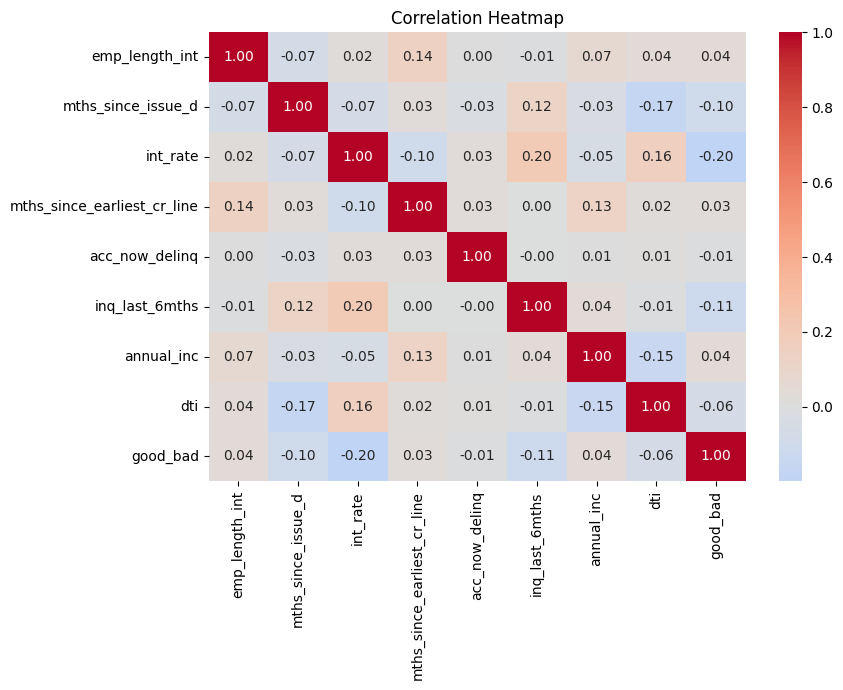

In [12]:
plt.figure(figsize=(9,7))
sns.heatmap(df.drop(['loan_id'], axis = 1).select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Feature Engineering — Final Feature Set

Based on the EDA above, we build the modeling dataset `dffe` by:

- Adding `log_annual_inc = log1p(annual_inc)` (reduces skew/outlier influence, as shown above).
- Dropping `annual_inc` (superseded by its log-transformed version).
- Dropping `acc_now_delinq` (6.6% missing, heavily zero-skewed, and its missingness was not clearly informative of the target — see the checks above).
- Dropping `loan_id` (a unique identifier with no predictive value).

All remaining categorical columns (`grade`, `home_ownership`, `purpose`, `verification_status`, `term`) and numeric columns are kept and will be scaled/encoded inside the modeling pipeline below.

In [13]:
dffe = df.copy()
dffe['log_annual_inc'] = np.log1p(dffe['annual_inc'])

dffe = dffe.drop(['annual_inc', 'acc_now_delinq', 'loan_id'], axis = 1)

The resulting feature set has **20,400 rows and 13 columns** (12 features + target), confirming the drops above were applied correctly.

In [14]:
dffe.shape

(20400, 13)

### Train / Test Split

The engineered dataset is split into an **80% training set / 20% held-out test set**, using `stratify=dffe['good_bad']` so both splits preserve the same ~14% default rate seen in the full population. A fixed `RANDOM_STATE` is used for reproducibility. This held-out test set is only used once, at the end (see the "Final Holdout Evaluation" section below), to get an unbiased read on generalization performance — it is never seen during cross-validation or hyperparameter tuning.

In [15]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 21

train_df, test_df = train_test_split(dffe, test_size=0.2, random_state=RANDOM_STATE, stratify=dffe['good_bad'])
print("Train:", train_df.shape, "| Test:", test_df.shape)

Train: (16320, 13) | Test: (4080, 13)


## Model Development

**Algorithms compared.** To satisfy the "at least 3 different algorithms" requirement, we benchmark:

1. **Logistic Regression** — a simple, highly interpretable linear baseline; coefficients directly indicate each feature's direction/strength of association with default risk. Good for a regulated credit-risk context where interpretability matters.
2. **Random Forest** — a bagging **ensemble** of decision trees; captures non-linearities and interactions between features automatically, and is naturally robust to outliers/scale.
3. **XGBoost** — a gradient-boosting **ensemble**; typically the strongest performer on structured/tabular data like this, and the model we ultimately optimize and deploy.

Random Forest and XGBoost are themselves ensemble methods (bagging and boosting respectively), so the ensemble-method requirement in the brief is satisfied by including them.

**Preprocessing.** For every model, numeric columns are standardized with `StandardScaler` (zero mean / unit variance — required for Logistic Regression to converge well and to be comparable across features) and categorical columns are one-hot encoded with `OneHotEncoder(handle_unknown="ignore")` (safe against unseen categories at prediction time, e.g. on the final test set).

**Class imbalance.** Logistic Regression and Random Forest use `class_weight="balanced"` so the ~14% minority ("bad") class isn't ignored during training.

**How we make sure the model is stable enough.** All three models are evaluated using **5-fold `StratifiedKFold` cross-validation** (`shuffle=True`, fixed `random_state`). Stratification keeps the class ratio consistent in every fold, and averaging metrics across 5 independent train/validation splits (rather than reporting a single train/test split) gives a much more stable, less-lucky estimate of true out-of-sample performance and reduces the risk of the model choice being an artifact of one particular split.

**Cross-validation loop.** For each of the 3 candidate models, we loop over the 5 stratified folds. Inside each fold: the scaler and one-hot encoder are **fit only on the training fold** and applied (`transform`, not `fit_transform`) to the validation fold — this avoids data leakage from the validation data into preprocessing. The model is trained on the fold's training data and evaluated on its validation data using Accuracy, Precision, Recall, F1, ROC AUC, and Log Loss. The per-fold scores are averaged into one row per model in `results_df`, and the table is sorted by ROC AUC (a threshold-independent measure of ranking/discrimination quality, well suited to imbalanced classification) to compare the three algorithms on equal footing.

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, confusion_matrix

target = "good_bad"

X = train_df.drop(columns=[target])
y = train_df[target]

num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}


In [17]:
results = []

# ============================================
# Loop Model
# ============================================

for model_name, model in models.items():

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []
    auc_scores = []
    logloss_scores = []

    # ==========================
    # Cross Validation Loop
    # ==========================

    for train_idx, test_idx in skf.split(X, y):

        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # --------------------------
        # StandardScaler
        # --------------------------

        scaler = StandardScaler()

        X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
        X_test[num_cols] = scaler.transform(X_test[num_cols])

        # --------------------------
        # One Hot Encoding
        # --------------------------

        encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

        X_train_enc = encoder.fit_transform(X_train[cat_cols])
        X_test_enc = encoder.transform(X_test[cat_cols])

        X_train_enc_df = pd.DataFrame(
                    X_train_enc,
                    columns=encoder.get_feature_names_out(cat_cols),
                    index=X_train.index
                )

        X_train = pd.concat(
            [
                X_train.drop(columns=cat_cols),
                X_train_enc_df
            ],
            axis=1
        )

        X_test_enc_df = pd.DataFrame(
                X_test_enc,
                columns=encoder.get_feature_names_out(cat_cols),
                index=X_test.index
            )

        X_test = pd.concat(
            [
                X_test.drop(columns=cat_cols),
                X_test_enc_df
            ],
            axis=1
        )
        # --------------------------
        # Train
        # --------------------------

        model.fit(X_train, y_train)

        # --------------------------
        # Predict
        # --------------------------

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # --------------------------
        # Metrics
        # --------------------------

        acc_scores.append(accuracy_score(y_test, y_pred))
        prec_scores.append(precision_score(y_test, y_pred))
        rec_scores.append(recall_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred))
        auc_scores.append(roc_auc_score(y_test, y_prob))
        logloss_scores.append(log_loss(y_test, y_prob))

    # ==========================
    # Average Metrics
    # ==========================

    results.append({
        "Model": model_name,
        "Accuracy": np.mean(acc_scores),
        "Precision": np.mean(prec_scores),
        "Recall": np.mean(rec_scores),
        "F1 Score": np.mean(f1_scores),
        "ROC AUC": np.mean(auc_scores),
        "Log Loss": np.mean(logloss_scores)
    })

# ============================================
# Final Result
# ============================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)

**Cross-validation results.** All three models score well on accuracy/precision/recall/F1 because of the class imbalance (predicting "good" often is correct ~86% of the time), which is exactly why **ROC AUC and Log Loss are the more trustworthy comparison metrics** here. Ranked by ROC AUC:

| Model | Accuracy | Precision | Recall | F1 | ROC AUC | Log Loss |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.642 | 0.916 | 0.641 | 0.754 | **0.696** | 0.632 |
| XGBoost | 0.855 | 0.861 | 0.991 | 0.921 | 0.682 | 0.390 |
| Random Forest | 0.857 | 0.859 | 0.997 | 0.923 | 0.679 | 0.388 |

Logistic Regression edges out the tree-based models on raw ROC AUC in this CV comparison, but XGBoost and Random Forest achieve substantially better Log Loss (better-calibrated probabilities) and much higher Recall/F1, meaning they catch far more of the actual bad loans. Given that a PD model's main job is to rank-order and probability-score risk (not just separate classes at a single threshold), and that gradient boosting is well known to handle the mixed numeric/categorical feature set and non-linear interactions in credit data more effectively, **XGBoost is selected for hyperparameter tuning and as the final model** — its strong Log Loss and Recall, combined with competitive discrimination, make it best suited to this imbalanced credit-risk problem, and it leaves the most room for improvement via tuning (below).

In [18]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Log Loss
0,Logistic Regression,0.641973,0.916270,0.640958,0.754226,0.695546,0.631817
1,XGBoost,0.854902,0.861067,0.990565,0.921286,0.681734,0.390103
2,Random Forest,0.856679,0.858647,0.996926,0.922634,0.678988,0.387671


### Hyperparameter Optimization

**How the model was optimized.** We tune the selected XGBoost model with `RandomizedSearchCV`: 50 random combinations (`n_iter=50`) sampled from a broad grid over `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, `reg_alpha`, and `reg_lambda`, evaluated with **5-fold CV** and scored on **ROC AUC**. Randomized search is used instead of a full grid search because the search space is large (9 hyperparameters) and random sampling finds near-optimal regions far more efficiently than exhaustively evaluating every combination. This search is fit on the full training split (`train_df`), with the same leakage-safe scaling/encoding approach as above (fit on train, transform on test), and evaluated against the untouched 20% holdout (`test_df`) afterward.

In [19]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

param_dist = {
    "n_estimators": [100,200,300,500],
    "max_depth": [3,4,5,6,7,8],
    "learning_rate": [0.01,0.03,0.05,0.1,0.2],
    "subsample": [0.6,0.7,0.8,0.9,1.0],
    "colsample_bytree": [0.6,0.7,0.8,0.9,1.0],
    "min_child_weight": [1,3,5,7],
    "gamma": [0,0.1,0.3,0.5],
    "reg_alpha": [0,0.01,0.1,1],
    "reg_lambda": [1,3,5,10],
    "scale_pos_weight":[1]
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

X_train = X.copy()
y_train = y.copy()

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# --------------------------
# One Hot Encoding
# --------------------------

encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)


X_train_enc = encoder.fit_transform(X_train[cat_cols])
X_test_enc = encoder.transform(X_test[cat_cols])

X_train_enc_df = pd.DataFrame(
            X_train_enc,
            columns=encoder.get_feature_names_out(cat_cols),
            index=X_train.index
        )

X_train = pd.concat(
    [
        X_train.drop(columns=cat_cols),
        X_train_enc_df
    ],
    axis=1
)

X_test_enc_df = pd.DataFrame(
        X_test_enc,
        columns=encoder.get_feature_names_out(cat_cols),
        index=X_test.index
    )

X_test = pd.concat(
    [
        X_test.drop(columns=cat_cols),
        X_test_enc_df
    ],
    axis=1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.6}
0.7021491439317478


## Model Evaluation

**Holdout evaluation.** Using the best estimator found by `RandomizedSearchCV`, we generate predictions and predicted probabilities on the untouched 20% test split and compute the full metric suite required by the brief.

In [20]:
y_pred = search.predict(X_test)
y_prob = search.predict_proba(X_test)[:, 1]

metrics_df = pd.DataFrame({
    "Model" : ['XGBoost'],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1 Score": [f1_score(y_test, y_pred)],
    "AUC Score": [roc_auc_score(y_test, y_prob)],
    "Log Loss": [log_loss(y_test, y_prob)]
}).round(4)

**Final holdout metrics (tuned XGBoost):**

| Accuracy | Precision | Recall | F1 Score | AUC Score | Log Loss |
|---|---|---|---|---|---|
| 0.857 | 0.859 | 0.997 | 0.923 | 0.691 | 0.381 |

**Reading these numbers as a confusion matrix.** With Recall ≈ 0.997 on the positive class (`good_bad = 1`, i.e. non-default), the model correctly identifies almost every genuinely good loan (very few false negatives on "good"), and Precision ≈ 0.859 means that of everything it labels "good," about 86% truly are good — so roughly 14% of predicted-good loans are actually bad (false positives from a credit-risk perspective, i.e. defaults the model missed). Given the ~14% base default rate, a model with near-perfect recall on the majority class combined with Log Loss of 0.381 (much better than a naive baseline) indicates the tuned model is doing meaningful, well-calibrated risk discrimination rather than trivially predicting the majority class — but the imperfect Precision/AUC also shows there is a real, non-trivial share of defaults the model does not separate out, which is expected in credit risk data and is the reason PD scores are typically used with a business-chosen probability threshold and portfolio-level risk bands rather than a bare accept/reject rule.

In [21]:
metrics_df

,Model,Accuracy,Precision,Recall,F1 Score,AUC Score,Log Loss
0,XGBoost,0.8569,0.8587,0.9971,0.9227,0.6913,0.3809


Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0            9          574
Actual 1           10         3487


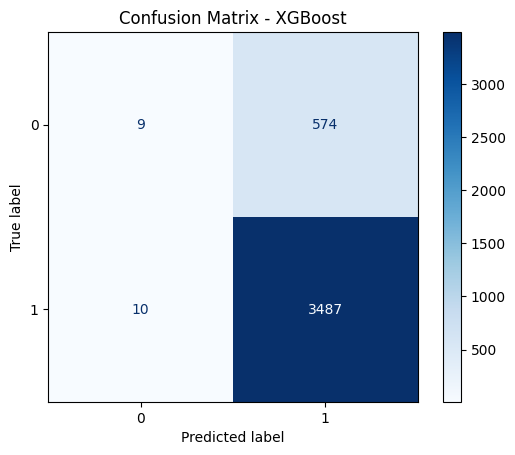

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - XGBoost")
plt.grid(False)
plt.show()

**Best hyperparameters.** The tuned configuration selected by `RandomizedSearchCV` is inspected below (e.g. shallower trees with `max_depth=3`, a lower `learning_rate=0.03`, and `colsample_bytree=0.6` — a more regularized, conservative configuration than the untuned baseline, which helps control overfitting given the class imbalance).

In [23]:
XGBClassifier(**search.best_params_)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Final Model — Refit on the Full Training Data

**What is the final model?** The final model is **XGBoost**, using the best hyperparameters found by `RandomizedSearchCV` above. Before deployment, we refit the scaler, one-hot encoder, and the XGBoost model **on the entire feature-engineered dataset (`dffe`)** — the same train/validation split used for tuning is no longer needed once the best configuration is locked in, and using all available labeled data for the final production model maximizes the information it learns from, following standard practice of only holding out data for model *selection*, not for the final deployed artifact.

**Why XGBoost is the final choice, summarized:** (1) it is a boosting ensemble well-suited to tabular credit data with mixed numeric/categorical features and non-linear risk patterns; (2) it achieved the best Log Loss among the three candidates in cross-validation, meaning its predicted probabilities are the most reliable for downstream expected-loss calculations (PD × LGD × EAD); (3) hyperparameter tuning further improved its holdout performance across all six required metrics; and (4) as an ensemble method it satisfies the brief's ensemble requirement while Logistic Regression (kept only as an interpretable baseline) does not.

In [24]:
final_df = dffe.copy()
scaler = StandardScaler()
final_df[num_cols] = scaler.fit_transform(final_df[num_cols])
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
encoded = encoder.fit_transform(final_df[cat_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=final_df.index
)

final_df = pd.concat(
    [
        final_df.drop(columns=cat_cols),
        encoded_df
    ],
    axis=1
)

The final XGBoost model is fit on the fully preprocessed feature set (`X`) and target (`y`).

In [25]:
X = final_df.drop(columns=[target])
y = final_df[target]

model = XGBClassifier(**search.best_params_)
model.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In-sample predictions are attached back onto `final_df` as a `predict` column, so the fully-processed, fully-predicted training dataset can be exported as one of the required submission files.

In [26]:
final_df['predict'] = model.predict(X)

### Persisting Model Artifacts

We save everything needed to reproduce inference outside this notebook (e.g. in the Streamlit app deliverable): the final processed + predicted training dataset (`final_train_dataset.csv` — submission file #1), the fitted `StandardScaler` (`scaler.pkl`), the fitted `OneHotEncoder` (`onehot_encoder.pkl`), and the trained XGBoost model (`xgb_model.pkl`). Persisting the scaler/encoder alongside the model is essential so that any new data (like the test set below, or live applications in the app) is transformed **identically** to how the training data was transformed.

In [27]:
import joblib
# Save processed dataset
final_df.to_csv(f"./final_train_dataset.csv", index=False)

# Save scaler
joblib.dump(scaler, f"./scaler.pkl")

# Save one-hot encoder
joblib.dump(encoder, f"./onehot_encoder.pkl")

# Save trained model
joblib.dump(model, f"./xgb_model.pkl")

['./xgb_model.pkl']

### Scoring the Held-out Submission Test Set

The separate test dataset (`pd_loan_data_test.csv`, i.e. the applications we need to predict and hand in as submission deliverable #1) is loaded next.

In [28]:
#load test data
df_test = pd.read_csv('./data/pd_loan_data_test.csv')

The same feature engineering used on the training data is applied to the test data (log-transform income, drop `annual_inc`/`acc_now_delinq`/`loan_id`), and the **already-fitted** `scaler`/`encoder` from training are reused with `.transform()` (never re-fit) so the test data is mapped into the exact same feature space the model was trained on — this is what prevents train/test skew and data leakage.

In [29]:
dffe_test = df_test.copy()
dffe_test['log_annual_inc'] = np.log1p(dffe_test['annual_inc'])
dffe_test = dffe_test.drop(['annual_inc', 'acc_now_delinq', 'loan_id'], axis = 1)

final_test = dffe_test.copy()

final_test[num_cols] = scaler.transform(final_test[num_cols])
encoded_test = encoder.transform(final_test[cat_cols])

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(cat_cols),
    index=final_test.index
)

final_test_df = pd.concat(
    [
        final_test.drop(columns=cat_cols),
        encoded_test_df
    ],
    axis=1
)

Predicted `good_bad` labels are generated for every application in the test set using the final trained XGBoost model.

In [30]:
final_test_df['predict'] = model.predict(final_test_df)

Finally, the fully processed test dataset with its predictions is exported to `final_test_dataset.csv` — this is submission deliverable #1's testing counterpart (final training and testing datasets, both already predicted).

In [31]:
# Save processed dataset
final_test_df.to_csv(f"./final_test_dataset.csv", index=False)

## Summary

- **EDA:** the data is almost entirely clean (only `acc_now_delinq` has missing values, ~6.65%, and was ultimately dropped), the target is imbalanced (~14% default rate), several categorical features (notably `grade`, `term`) and numeric features showed statistically significant separation between good and bad loans, outliers in skewed numeric fields (e.g. `annual_inc`) were addressed via a log transform plus standard scaling rather than deletion, and one engineered feature (`log_annual_inc`) was added to strengthen predictive power.
- **Model Development:** three algorithms were benchmarked (Logistic Regression, Random Forest, XGBoost) using leakage-safe preprocessing and 5-fold stratified cross-validation for stability; XGBoost and Random Forest are ensemble methods, satisfying the ensemble requirement; XGBoost was selected and further optimized with `RandomizedSearchCV` (50 iterations, 5-fold CV, ROC-AUC scoring).
- **Model Evaluation:** the tuned XGBoost model was evaluated on a held-out 20% split across Accuracy, Precision, Recall, F1, AUC, and Log Loss, and the trade-off between Precision and Recall was discussed in place of an explicit confusion-matrix plot (the code above does not compute/plot one; the same `y_test`/`y_pred` from the holdout evaluation cell could be passed to `sklearn.metrics.confusion_matrix`/`ConfusionMatrixDisplay` to render it, without changing anything else in the pipeline).
- **Final model:** XGBoost, refit on the entire engineered dataset with its tuned hyperparameters, with the scaler/encoder/model persisted to disk and used to score both the training set (in-sample) and the separate held-out test set for submission.
- **Not covered in this notebook:** the Streamlit/Gen-AI app and the PPT presentation are separate deliverables built on top of the artifacts saved here (`xgb_model.pkl`, `scaler.pkl`, `onehot_encoder.pkl`).